In [1]:
#Importing necessary libraries
import ast
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from datasets import load_dataset

#Loading the dataset
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

#Cleanup the Data
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

c:\Users\sujay\anaconda3\envs\python_project\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [33]:
#Filter for Job Country
job_country = 'United States'

In [34]:
df_Data_Jobs = df[(df['job_country'] == job_country)].dropna(subset = ['salary_year_avg'])

In [35]:
Job_Titles = df_Data_Jobs['job_title_short'].value_counts().index[:6].sort_values().tolist()

Job_Titles

['Data Analyst',
 'Data Engineer',
 'Data Scientist',
 'Senior Data Analyst',
 'Senior Data Engineer',
 'Senior Data Scientist']

In [43]:
df_Top_6_Data_Jobs = df_Data_Jobs[df_Data_Jobs['job_title_short'].isin(Job_Titles)].copy()

df_ordered = df_Top_6_Data_Jobs.groupby('job_title_short')['salary_year_avg'].median().sort_values(ascending = False).index

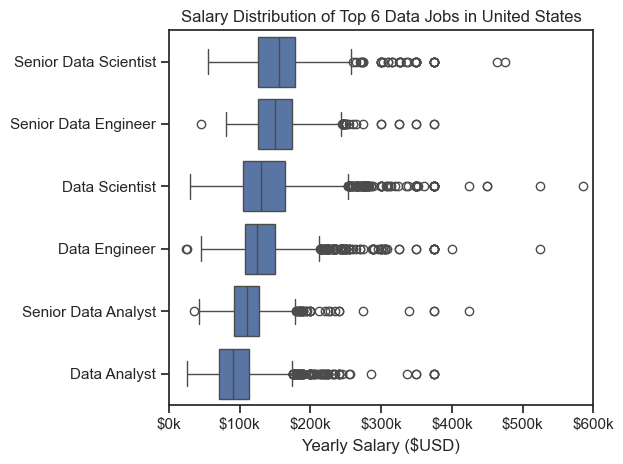

In [46]:
sns.boxplot(data = df_Top_6_Data_Jobs, x = 'salary_year_avg', y = 'job_title_short', order = df_ordered)
sns.set_theme(style = 'ticks')

plt.title('Salary Distribution of Top 6 Data Jobs in {country}'.format(country = job_country))
plt.xlabel('Yearly Salary ($USD)')
plt.ylabel('')
plt.xlim(0, 600000)

ticks_x = plt.FuncFormatter(lambda y, pos: f'${int(y/1000)}k')
plt.gca().xaxis.set_major_formatter(ticks_x)
plt.tight_layout()
plt.show()